# **RQ4: How does the target distribution structure affect curvature-dependent RFM performance?**

## **Results**

- All helper utilities live in `visualize_run.py` (paths/globs, metrics I/O, and plotting).
- A run directory is expected to contain `artifacts/final_fixed_eval_outputs.pt` and `metrics.json`.

In [7]:
from visualize_run import get_metrics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats


### Define output paths
- Specify output globs where outputs live

In [2]:
mog_paths = [
    '../outputs/runs/mog/euclidean/general/*',
    '../outputs/runs/mog/sphere/general/*',
    '../outputs/runs/mog/poincare/general/*',
]

gtg_paths = [
    '../outputs/runs/gtg/euclidean/general/*',
    '../outputs/runs/gtg/sphere/general/*',
    '../outputs/runs/gtg/poincare/general/*',
]

gaussian_ring_paths = [
    #TODO: check
    '../outputs/runs/general_fm/fm/*'
]

checkerboard_paths = [
    '../outputs/runs/checkerboard/euclidean/general/*',
    '../outputs/runs/checkerboard/sphere/general/*',
    '../outputs/runs/checkerboard/poincare/general/*',
]

### Load results
- Set visualize to True to save plots of final flow matching distribution.
- Results are saved to csv by default.
- Comment out ```get_method()``` lines to load results from csv.

In [3]:
# Load and save into csv (comment out if applicable)

# metrics_gtg = get_metrics([], gtg_paths, visualize=False, save=True, out_dir='runs/gtg')
# metrics_mog = get_metrics([], mog_paths, visualize=False, save=True, out_dir='runs/mog')
# metrics_gaussian_ring = get_metrics([], gaussian_ring_paths, visualize=False, save=True, out_dir='runs/gaussian_ring')
# metrics_checkerboard = get_metrics([], checkerboard_paths, visualize=True, save=True, out_dir='runs/checkerboard')

# Retrieve from csv
metrics_gtg = pd.read_csv('runs/gtg/metrics.csv')
metrics_mog = pd.read_csv('runs/mog/metrics.csv')
metrics_gaussian_ring = pd.read_csv('runs/gaussian_ring/metrics.csv')
metrics_checkerboard = pd.read_csv('runs/checkerboard/metrics.csv')

### Specify Results
- Change the experiment variable to applicable experiment
- change the x or y axis to get metrics

In [4]:
def print_metrics(experiment: pd.DataFrame, x: str, y: str):
    print(f"Available metrics:")
    print(", ".join(map(str, experiment.columns.tolist())))
    print()
    
    selected = experiment[[experiment.columns[0], x, y]]
    print(selected.to_string(index=False))

In [5]:
# metrics_gtg, metrics_mog, metrics_gaussian_ring, metrics_checkerboard
experiment = metrics_gaussian_ring
print_metrics(experiment, x='dim', y='test_sample/sinkhorn_knopp')

Available metrics:
Unnamed: 0, train/loss, train/loss_step, lr-AdamW, train/loss_epoch, nfe, integ_error, val/rfm_loss, val/rfm_loss_epoch, val/loss, val/loss_epoch, val/loss_best, test/loss, test_vec/rfm_loss, test_vec/alignment, test_vec/finite_fraction, test_vec/norm_mean, test_vec/norm_max, test_vec/norm_std, test_vec/norm_p95, test_vec/tangency_violation_abs, test_vec/tangency_violation_rel, test_sample/sinkhorn_knopp, test_sample/tangent_sinkhorn_knopp, test_sample/tangent_to_geodesic_sinkhorn_ratio, test_sample/epsilon_coverage, test_sample/epsilon_precision, test_sample/frechet_variance_pred, test_sample/frechet_variance_target, test_sample/frechet_variance_ratio, test_sample/dispersion_predicted, test_sample/dispersion_target, test_sample/dispersion_ratio, test_sample/volume_scaling_mean_pred, test_sample/volume_scaling_mean_target, test_sample/volume_scaling_variance_pred, test_sample/volume_scaling_variance_target, test_sample/volume_scaling_gap_target_minus_pred, test_sampl

### Plots RQ 4

In [ ]:

PERF_COL     = "test_sample/sinkhorn_knopp"
VGG_COL      = "test_sample/volume_scaling_gap_target_minus_pred"
DIM_COL      = "dim"
MANIFOLD_COL = "manifold"
CURV_COL     = "curvature"

EUCLIDEAN_NAME = "euclidean"
POINCARE_NAME  = "poincare"
SPHERE_NAME    = "sphere"

# S^n stored as dim=n+1 (ambient). True -> subtract 1 for intrinsic dim.
SPHERE_DIM_MINUS_ONE = True

# Error bars: "sem" or "std"
ERROR_BAR = "sem"

# Curvatures shown in the main-text line plot (None = show all)
SELECTED_CURVATURES = [1, 3, 10]

# Curvature ordering: "abs" = by magnitude, "numeric" = signed
CURVATURE_ORDER = "abs"



def signed_log1p(x):
    return np.sign(x) * np.log10(1 + np.abs(x))

def safe_log10(x):
    x = pd.to_numeric(x, errors="coerce")
    return np.log10(x.where(x > 0))

def error_value(x, kind="sem"):
    x = pd.Series(x).replace([np.inf, -np.inf], np.nan).dropna()
    if len(x) <= 1: return 0.0
    if kind == "std": return x.std(ddof=1)
    return x.std(ddof=1) / np.sqrt(len(x))

def mean_sem(x):
    x = pd.Series(x).replace([np.inf, -np.inf], np.nan).dropna()
    if len(x) == 0: return np.nan, np.nan, 0
    mean = x.mean()
    if len(x) == 1: return mean, 0.0, 1
    return mean, x.std(ddof=1) / np.sqrt(len(x)), len(x)

def nice_dim_label(x):
    if pd.isna(x): return ""
    return str(int(x)) if float(x).is_integer() else f"{x:g}"

def nice_curv_label(x):
    if pd.isna(x): return "NA"
    try: return f"{float(x):g}"
    except Exception: return str(x)

def display_manifold_name(m):
    return {POINCARE_NAME: "Hyperbolic", SPHERE_NAME: "Spherical",
            EUCLIDEAN_NAME: "Euclidean"}.get(m, str(m))

def ordered_curvatures(values, order="abs"):
    values = pd.Series(values).dropna().unique()
    def key(x):
        try:
            xf = float(x)
            return (abs(xf), xf) if order == "abs" else (xf,)
        except Exception: return (str(x),)
    return sorted(values, key=key)

def ordered_manifolds(values):
    preferred = [POINCARE_NAME, SPHERE_NAME, EUCLIDEAN_NAME]
    values = list(pd.Series(values).dropna().unique())
    return [m for m in preferred if m in values] + [m for m in values if m not in preferred]

def ordered_values_numeric(values, use_abs=False):
    values = pd.Series(values).dropna().unique()
    def key(x):
        try:
            xf = float(x)
            return (abs(xf), xf) if use_abs else (xf,)
        except Exception: return (str(x),)
    return sorted(values, key=key)



def add_relative_to_euclidean(df_prepared, metric_col, out_col):
    df = df_prepared.copy()
    euc = (
        df[df[MANIFOLD_COL].eq(EUCLIDEAN_NAME)]
        .groupby("compare_dim", as_index=False)
        .agg(euc_metric=(metric_col, "mean"))
    )
    df = df.merge(euc, on="compare_dim", how="left")
    df[out_col] = df[metric_col] / df["euc_metric"]
    return df

def prepare_rq3_dataframe(df):
    """
    Adds: compare_dim, euc_perf/euc_vgg baselines,
    rel_perf, log_rel_perf, vgg_gap_vs_euc, signed_log_vgg_gap.
    """
    df = df.copy()
    df[PERF_COL] = pd.to_numeric(df[PERF_COL], errors="coerce")
    df[VGG_COL]  = pd.to_numeric(df[VGG_COL],  errors="coerce")
    df[DIM_COL]  = pd.to_numeric(df[DIM_COL],  errors="coerce")

    df["compare_dim"] = df[DIM_COL]
    if SPHERE_DIM_MINUS_ONE:
        mask = df[MANIFOLD_COL].eq(SPHERE_NAME)
        df.loc[mask, "compare_dim"] = df.loc[mask, DIM_COL] - 1

    euc = (
        df[df[MANIFOLD_COL].eq(EUCLIDEAN_NAME)]
        .groupby("compare_dim", as_index=False)
        .agg(euc_perf=(PERF_COL, "mean"), euc_vgg=(VGG_COL, "mean"))
    )
    euc["euc_vgg"] = euc["euc_vgg"].fillna(0.0)
    df = df.merge(euc, on="compare_dim", how="left")

    df["rel_perf"]        = df[PERF_COL] / df["euc_perf"]
    df["log_rel_perf"]    = np.log10(df["rel_perf"])
    df["vgg_gap_vs_euc"]  = df[VGG_COL] - df["euc_vgg"]
    df["signed_log_vgg_gap"] = signed_log1p(df["vgg_gap_vs_euc"])
    return df


rq3_prepared = prepare_rq3_dataframe(metrics_gtg)
print(f"Loaded {len(rq3_prepared)} rows.")
print(f"Manifolds:  {sorted(rq3_prepared[MANIFOLD_COL].dropna().unique())}")
print(f"Curvatures: {sorted(rq3_prepared[CURV_COL].dropna().unique())}")
print(f"Dimensions: {sorted(rq3_prepared['compare_dim'].dropna().unique())}")


Loaded 198 rows.
Manifolds:  ['euclidean', 'poincare', 'sphere']
Curvatures: [0.0, 1.0, 2.0, 3.0, 5.0, 10.0]
Dimensions: [2, 3, 16, 64, 256, 512]


In [11]:
def plot_wasserstein_vs_curvature(df, title_suffix=""):
    """
    One subplot per target distribution.
    x: curvature
    y: Wasserstein
    lines: one per dimensionality
    """
    df = df.copy()
    df = df.replace([np.inf, -np.inf], np.nan)

    # Sphere intrinsic dimension correction
    df["compare_dim"] = df[DIM_COL]
    if SPHERE_DIM_MINUS_ONE:
        mask = df[MANIFOLD_COL].eq(SPHERE_NAME)
        df.loc[mask, "compare_dim"] = df.loc[mask, DIM_COL] - 1

    grouped = (
        df.groupby([CURV_COL, "compare_dim"], as_index=False)
        .agg(
            y_mean=(PERF_COL, "mean"),
            y_sem=(PERF_COL, lambda x: error_value(x, ERROR_BAR)),
            n=(PERF_COL, "count"),
        )
    )

    all_dims = ordered_values_numeric(grouped["compare_dim"])
    cmap = plt.cm.viridis
    color_map = {
        d: cmap(v)
        for d, v in zip(all_dims, np.linspace(0.1, 0.9, len(all_dims)))
    }

    fig, ax = plt.subplots(figsize=(6.5, 4.8))

    for dim in all_dims:
        sub = grouped[grouped["compare_dim"].eq(dim)].sort_values(CURV_COL)
        if sub.empty:
            continue

        color = color_map[dim]

        c = sub[CURV_COL].values
        ym = sub["y_mean"].values
        ys = sub["y_sem"].values

        ax.fill_between(c, ym - ys, ym + ys,
                        alpha=0.15, color=color)

        ax.errorbar(
            c, ym, yerr=ys,
            fmt="o-",
            color=color,
            markersize=6,
            capsize=4,
            linewidth=2,
            label=f"d={nice_dim_label(dim)}",
        )

    ax.set_xlabel("Curvature", fontsize=11)
    ax.set_ylabel("Wasserstein distance", fontsize=11)

    ax.set_title(title_suffix, fontsize=12)

    ax.legend(frameon=False, title="Dimension", fontsize=9)

    ax.grid(alpha=0.2)

    fig.tight_layout()

    return fig, ax

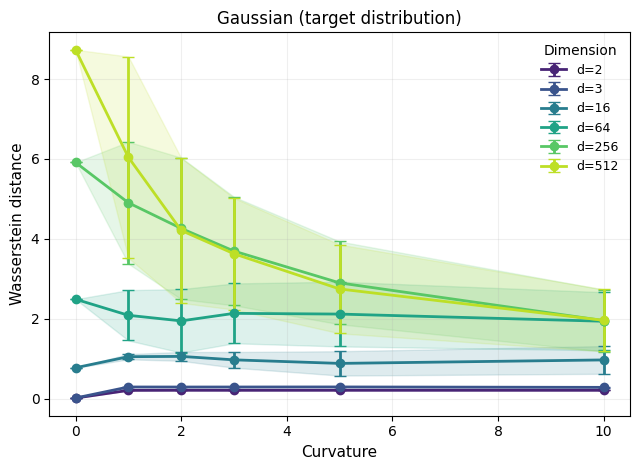

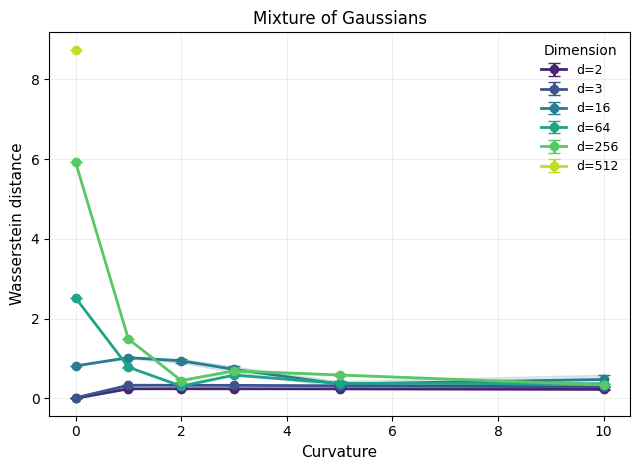

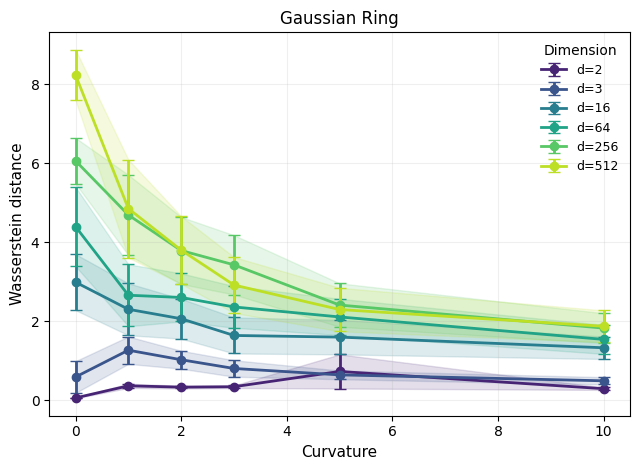

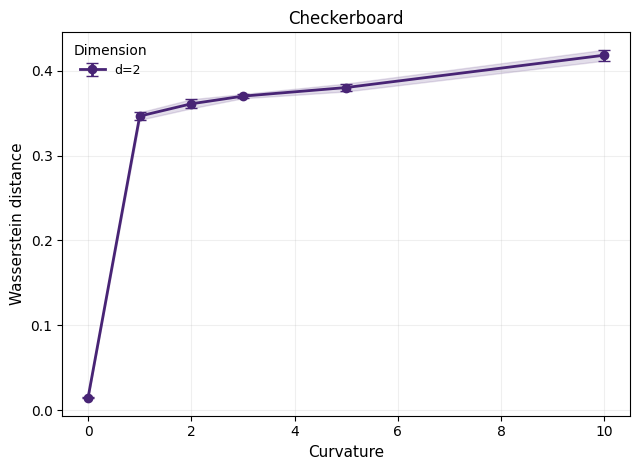

In [13]:
fig_g, _ = plot_wasserstein_vs_curvature(
    metrics_gtg,
    title_suffix="Gaussian (target distribution)"
)
plt.show()

fig_mog, _ = plot_wasserstein_vs_curvature(
    metrics_mog,
    title_suffix="Mixture of Gaussians"
)
plt.show()

fig_ring, _ = plot_wasserstein_vs_curvature(
    metrics_gaussian_ring,
    title_suffix="Gaussian Ring"
)
plt.show()

fig_cb, _ = plot_wasserstein_vs_curvature(
    metrics_checkerboard,
    title_suffix="Checkerboard"
)
plt.show()